# Comparing the orbital binding energies of ozone against experiment

The KI functional predicts a binding energy for *every* occupied orbital, which can be compared against gas-phase photoemission spectroscopy.

This is the completed solution notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from koopmans import io

## Experimental binding energies

The array below holds the experimental binding energies (eV) of the nine occupied orbitals of ozone, ordered from the most tightly bound orbital to the HOMO. Here we keep only the **three outermost (frontier) orbitals** and mark every other entry as `np.nan` so it is not drawn.

Source: *Chemical Physics Letters* **375**, 76 (2003), [doi:10.1016/S0009-2614(03)00818-2](https://doi.org/10.1016/S0009-2614(03)00818-2).

In [2]:
# only the three outermost (frontier) orbitals have reliable experimental values used here
exp_binding_energies = np.array(
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 13.54, 13.00, 12.73])

## 1. Load the koopmans workflow

In [3]:
wf = io.read('ozone.pkl')

## 2. Extract the KI eigenvalues

The last calculation in the workflow is the final KI calculation. Before extracting anything, take a look at what its `results` dictionary contains:

In [4]:
final_calc = wf.calculations[-1]
final_calc.results.keys()

dict_keys(['energy', 'odd_energy', 'homo_energy', 'lumo_energy', 'mp1_energy', 'mp2_energy', 'eigenvalues', 'lambda_ii', 'orbital_data', 'convergence', 'job_done', 'walltime', 'lambda', 'bare lambda'])

**TODO:** extract the eigenvalues (in eV) of the nine *occupied* orbitals from `final_calc.results`, then convert them into binding energies.

Hints:
- `results['eigenvalues']` is indexed as `[spin][band]`; ozone is closed-shell, so the two spin channels are identical.
- There are 9 occupied orbitals and 1 empty orbital.
- The binding energy of an orbital is minus its eigenvalue.

In [5]:
ki_eigenvalues = np.array(final_calc.results['eigenvalues'][0][:9])
ki_binding_energies = -ki_eigenvalues
print('KI binding energies (eV):', ki_binding_energies)

KI binding energies (eV): [40.1865 32.9126 24.2279 19.6844 19.4901 19.2698 13.604  12.7622 12.5201]


## 3. Extract the PBE eigenvalues

The PBE eigenvalues come from the final initialization calculation, `04-dft_init_nspin2`. List every calculation in the workflow and the directory it ran in:

In [6]:
for calc in wf.calculations:
    print(calc.directory)

01-koopmans-dscf/01-initialization/01-dft_init_nspin1
01-koopmans-dscf/01-initialization/02-dft_init_nspin2_dummy
01-koopmans-dscf/01-initialization/04-dft_init_nspin2
01-koopmans-dscf/02-calculate-screening-via-dscf/01-iteration-1/01-ki
01-koopmans-dscf/02-calculate-screening-via-dscf/01-iteration-1/02-orbital-1/01-dft_n-1
01-koopmans-dscf/02-calculate-screening-via-dscf/01-iteration-1/03-orbital-2/01-dft_n-1
01-koopmans-dscf/02-calculate-screening-via-dscf/01-iteration-1/04-orbital-3/01-dft_n-1
01-koopmans-dscf/02-calculate-screening-via-dscf/01-iteration-1/05-orbital-4/01-dft_n-1
01-koopmans-dscf/02-calculate-screening-via-dscf/01-iteration-1/06-orbital-5/01-dft_n-1
01-koopmans-dscf/02-calculate-screening-via-dscf/01-iteration-1/07-orbital-6/01-dft_n-1
01-koopmans-dscf/02-calculate-screening-via-dscf/01-iteration-1/08-orbital-7/01-dft_n-1
01-koopmans-dscf/02-calculate-screening-via-dscf/01-iteration-1/09-orbital-8/01-dft_n-1
01-koopmans-dscf/02-calculate-screening-via-dscf/01-iterat

**TODO:** locate the appropriate DFT`04-dft_init_nspin2` calculation among `wf.calculations`, extract the eigenvalues of its nine occupied orbitals, and convert them into binding energies.

In [7]:
pbe_calc = wf.calculations[0]
pbe_eigenvalues = np.array(pbe_calc.results['eigenvalues'][0][:9])
pbe_binding_energies = -pbe_eigenvalues

## 4. Plot the binding energies against experiment

**TODO:** scatter the KI and PBE binding energies against the experimental ones, and add a diagonal `y = x` line so that points lying on the line correspond to perfect agreement. Orbitals with no experimental value (`np.nan`) will simply not be drawn.

ValueError: 'auto' is not a valid value for loc; supported values are 'best', 'upper right', 'upper left', 'lower left', 'lower right', 'right', 'center left', 'center right', 'lower center', 'upper center', 'center'

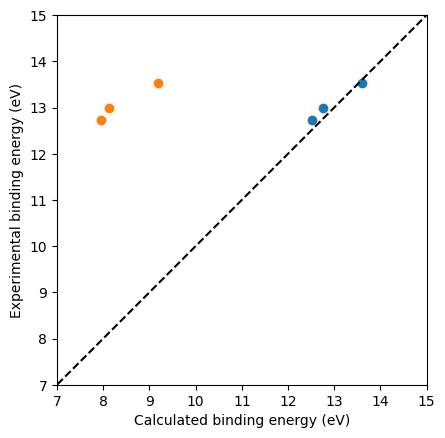

In [ ]:
fig, ax = plt.subplots()

ax.scatter(ki_binding_energies, exp_binding_energies, label='KI')

ax.scatter(pbe_binding_energies, exp_binding_energies, label='PBE')

lims = [5, 26]
ax.plot(lims, lims, 'k--')

ax.set_xlabel('Calculated binding energy (eV)')
ax.set_ylabel('Experimental binding energy (eV)')
ax.set_xlim(7, 15)
ax.set_ylim(7, 15)
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='lower right')
plt.show()

<details>
<summary><b>Solution</b></summary>

```python
ax.scatter(ki_binding_energies, exp_binding_energies, label='KI')
ax.scatter(pbe_binding_energies, exp_binding_energies, label='PBE')
lims = [5, 26]
ax.plot(lims, lims, 'k--')
```

</details>